In [ ]:
!pip install torch torchvision captum matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models

from captum.attr import IntegratedGradients, Saliency, LayerGradCam3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/xai_dataset/train",
    transform=transform
)

loader = DataLoader(dataset, batch_size=1, shuffle=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
ig = IntegratedGradients(model)
saliency = Saliency(model)
gradcam = LayerGradCam(model, model.layer4)

In [ ]:
def get_explanations(input_img, target):
    input_img = input_img.to(device)
    input_img = input_img.clone().detach().requires_grad_(True)

    ig_attr = ig.attribute(input_img.unsqueeze(0), target=target)
    sal_attr = saliency.attribute(input_img.unsqueeze(0), target=target)
    gc_attr = gradcam.attribute(input_img.unsqueeze(0), target=target)

    gc_attr = F.interpolate(
        gc_attr,
        size=(224, 224),
        mode='bilinear',
        align_corners=False
    )

    gc_attr = gc_attr.squeeze()
    if isinstance(gc_attr, torch.Tensor):
      gc_attr = gc_attr.detach().cpu().numpy()

    gc_attr = np.maximum(gc_attr, 0)
    gc_attr = gc_attr / (gc_attr.max() + 1e-8)

    ixg_attr = input_x_gradient(input_img, target)
    sg_attr = smoothgrad(input_img, target)

    return {
        "IG": ig_attr.squeeze().cpu().detach().numpy(),
        "Saliency": sal_attr.squeeze().cpu().detach().numpy(),
        "GradCAM": gc_attr.squeeze(),
        "IxG": ixg_attr,
        "SmoothGrad": sg_attr
    }

In [ ]:
def input_x_gradient(input_img, target):
    input_img = input_img.unsqueeze(0).to(device)
    input_img = input_img.clone().detach().requires_grad_(True)

    output = model(input_img)
    loss = output[0, target]
    loss.backward()

    return (input_img.grad * input_img).squeeze().cpu().detach().numpy()

In [ ]:
def smoothgrad(input_img, target, samples=10, noise_level=0.1):
    grads = []

    for _ in range(samples):
        model.zero_grad()
        noise = torch.randn_like(input_img) * noise_level
        noisy_img = input_img + noise
        noisy_img = noisy_img.unsqueeze(0).to(device)
        noisy_img = noisy_img.clone().detach().requires_grad_(True)

        output = model(noisy_img)
        loss = output[0, target]
        loss.backward()

        grads.append(noisy_img.grad.squeeze().cpu().detach().numpy())

    return np.mean(grads, axis=0)

In [ ]:
attr_functions = {
    "IG": lambda x, t: ig.attribute(x.unsqueeze(0).to(device), target=t)
                        .squeeze().cpu().detach().numpy(),

    "Saliency": lambda x, t: saliency.attribute(x.unsqueeze(0).to(device), target=t)
                        .squeeze().cpu().detach().numpy(),

    "GradCAM": lambda x, t: gradcam.attribute(x.unsqueeze(0).to(device), target=t)
                        .squeeze().cpu().detach().numpy(),

    "IxG": input_x_gradient,

    "SmoothGrad": smoothgrad
}

In [ ]:
def deletion_metric(model, image, attribution, target, steps=10, mode="black"):
    image = image.clone().to(device)

    attribution = np.abs(attribution)

    if attribution.ndim == 3:
        attribution = attribution.mean(axis=0)

    import cv2
    attribution = cv2.GaussianBlur(attribution, (11, 11), 0)

    flat = attribution.flatten()
    indices = np.argsort(-flat)

    total_pixels = flat.shape[0]
    step_size = total_pixels // steps

    img_np = image.cpu().detach().numpy().copy()
    scores = []

    for i in range(steps):
        idx = indices[i*step_size:(i+1)*step_size]

        for id in idx:
            h = id // 224
            w = id % 224

            if mode == "black":
                img_np[:, h, w] = 0

            elif mode == "blur":
                h1, h2 = max(0, h-1), min(223, h+1)
                w1, w2 = max(0, w-1), min(223, w+1)
                img_np[:, h, w] = np.mean(img_np[:, h1:h2+1, w1:w2+1], axis=(1,2))

            elif mode == "noise":
                img_np[:, h, w] = np.random.normal(0, 0.2, size=3)

        img_tensor = torch.tensor(img_np).unsqueeze(0).to(device)
        out = model(img_tensor)
        prob = F.softmax(out, dim=1)[0, target].item()
        scores.append(prob)

    return np.mean(scores)

In [ ]:
def sensitivity_metric(image, target, attr_fn):
    noise = torch.randn_like(image) * 0.05

    attr1 = attr_fn(image, target)
    attr2 = attr_fn(image + noise, target)

    return np.mean(np.abs(attr1 - attr2))

In [ ]:
def insertion_metric(model, image, attribution, target, steps=10, mode="black"):
    image = image.clone().to(device)

    attribution = np.abs(attribution)

    if attribution.ndim == 3:
        attribution = attribution.mean(axis=0)

    import cv2
    attribution = cv2.GaussianBlur(attribution, (11, 11), 0)

    flat = attribution.flatten()
    indices = np.argsort(-flat)

    total_pixels = flat.shape[0]
    step_size = total_pixels // steps

    baseline = torch.zeros_like(image).cpu().numpy()
    image_np = image.cpu().numpy()

    scores = []

    for i in range(steps):
        idx = indices[i*step_size:(i+1)*step_size]

        for id in idx:
            h = id // 224
            w = id % 224

            if mode == "black":
                baseline[:, h, w] = image_np[:, h, w]

            elif mode == "blur":
                h1, h2 = max(0, h-1), min(223, h+1)
                w1, w2 = max(0, w-1), min(223, w+1)
                baseline[:, h, w] = np.mean(image_np[:, h1:h2+1, w1:w2+1], axis=(1,2))

            elif mode == "noise":
                baseline[:, h, w] = np.random.normal(0, 0.2, size=3)

        img_tensor = torch.tensor(baseline).unsqueeze(0).to(device)
        out = model(img_tensor)
        prob = F.softmax(out, dim=1)[0, target].item()
        scores.append(prob)

    return np.mean(scores)

In [ ]:
def infidelity_metric(model, image, attribution, target, samples=10):
    image = image.to(device)
    attribution = torch.tensor(attribution).to(device)

    if attribution.dim() == 2:
        attribution = attribution.unsqueeze(0)  # (1, H, W)

    if attribution.shape[-1] != image.shape[-1]:
        attribution = F.interpolate(
            attribution.unsqueeze(0),  # (1, C, H, W)
            size=(image.shape[1], image.shape[2]),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

    attribution = attribution / (attribution.abs().sum() + 1e-8)

    scores = []

    for _ in range(samples):
        noise = torch.randn_like(image) * 0.01
        perturbed = image + noise

        output1 = model(image.unsqueeze(0))
        output2 = model(perturbed.unsqueeze(0))

        diff = output1[0, target] - output2[0, target]
        approx = torch.sum(attribution * noise, dim=(0,1,2))

        scores.append((diff - approx).item() ** 2)

    return np.mean(scores)

In [ ]:
methods = ["IG", "Saliency", "GradCAM", "IxG", "SmoothGrad"]
metrics = [
    "deletion_black", "deletion_blur", "deletion_noise",
    "insertion_black", "insertion_blur", "insertion_noise",
    "infidelity", "sensitivity"
]

results = {
    method: {metric: [] for metric in metrics}
    for method in methods
}

model.eval()

for i, (img, _) in enumerate(loader):
    if i >= 200:
        break

    img = img.to(device)


    output = model(img)
    target = output.argmax(dim=1).item()

    explanations = get_explanations(img.squeeze(), target)

    for method in methods:
        attr = explanations[method]


        attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

        for mode in ["black", "blur", "noise"]:
          results[method][f"deletion_{mode}"].append(
            deletion_metric(model, img.squeeze(), attr, target, mode=mode)
          )

        for mode in ["black", "blur", "noise"]:
          results[method][f"insertion_{mode}"].append(
              insertion_metric(model, img.squeeze(), attr, target, mode=mode)
          )

        results[method]["infidelity"].append(
            infidelity_metric(model, img.squeeze(), attr, target)
        )

        results[method]["sensitivity"].append(
            sensitivity_metric(img.squeeze(), target, attr_functions[method])
        )

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


In [ ]:
avg_results = {
    method: {
        metric: np.mean(results[method][metric])
        for metric in metrics
    }
    for method in methods
}

print(avg_results)

{'IG': {'deletion_black': 0.029006987366472864, 'deletion_blur': 0.4481999843918939, 'deletion_noise': 0.029700226391715493, 'insertion_black': 0.1769459884045495, 'insertion_blur': 0.09775979835336518, 'insertion_noise': 0.0013199974549997933, 'infidelity': 0.007968493584493357, 'sensitivity': 0.012821237}, 'Saliency': {'deletion_black': 0.06995308970618179, 'deletion_blur': 0.6468025541832904, 'deletion_noise': 0.07298956282507106, 'insertion_black': 0.33976454262153966, 'insertion_blur': 0.21924599212963203, 'insertion_noise': 0.001427265028044985, 'infidelity': 0.008109302895033059, 'sensitivity': 0.009568839}, 'GradCAM': {'deletion_black': 0.07424446427379489, 'deletion_blur': 0.6383630513995886, 'deletion_noise': 0.07004758579973737, 'insertion_black': 0.5255526786975523, 'insertion_blur': 0.3817762964897477, 'insertion_noise': 0.0011063335163853621, 'infidelity': 0.0079599697327126, 'sensitivity': 0.016064055}, 'IxG': {'deletion_black': 0.04081543108081341, 'deletion_blur': 0.44

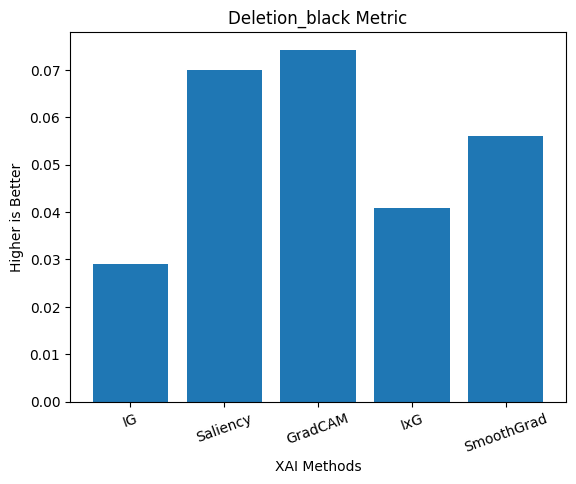

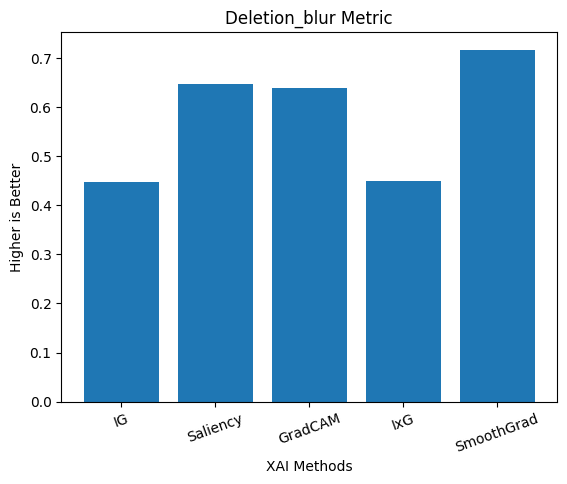

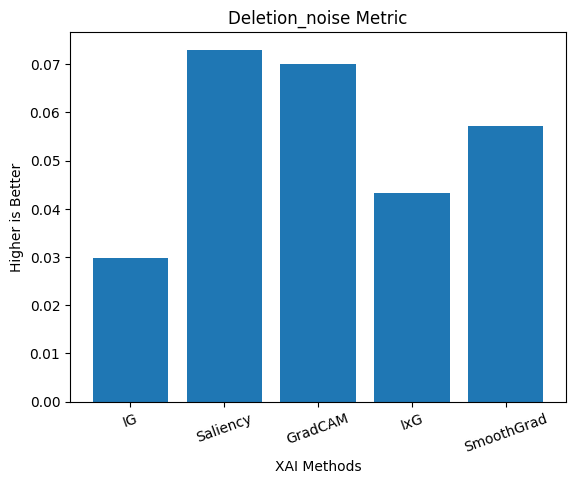

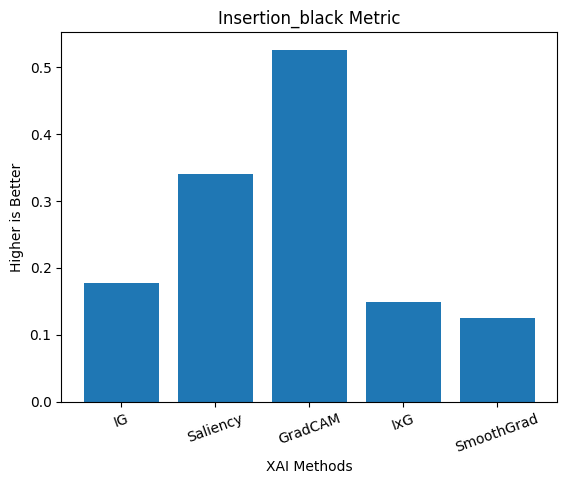

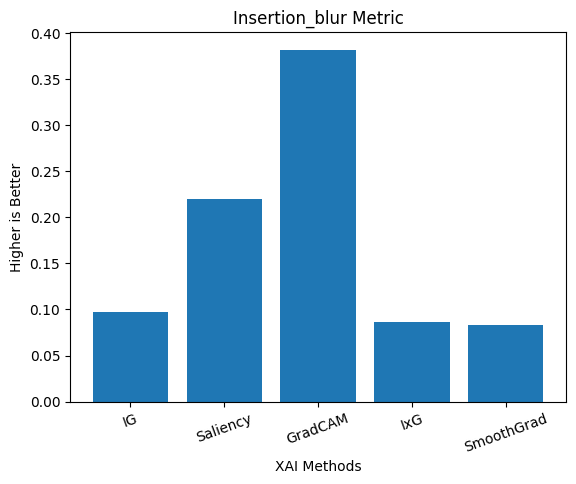

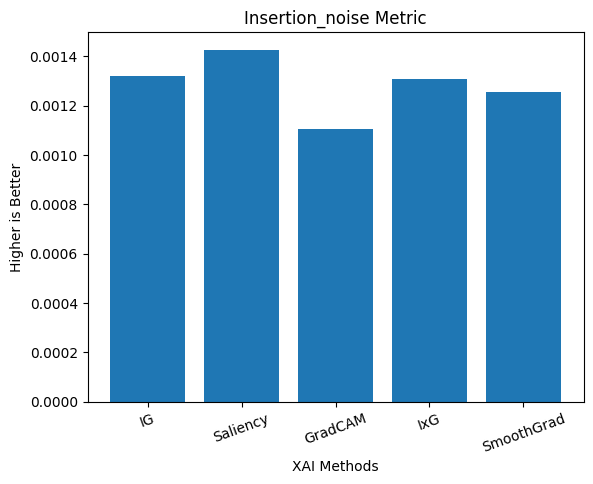

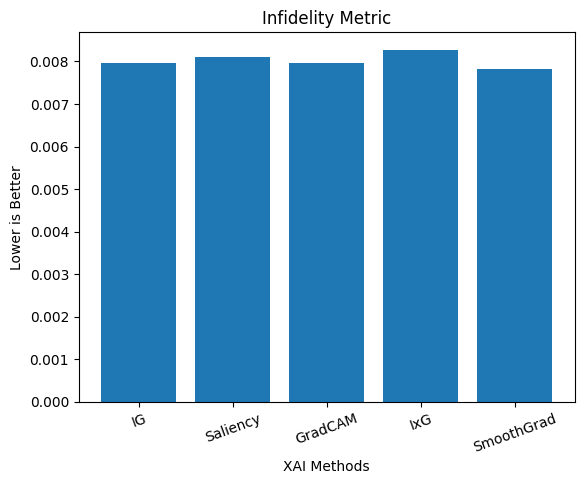

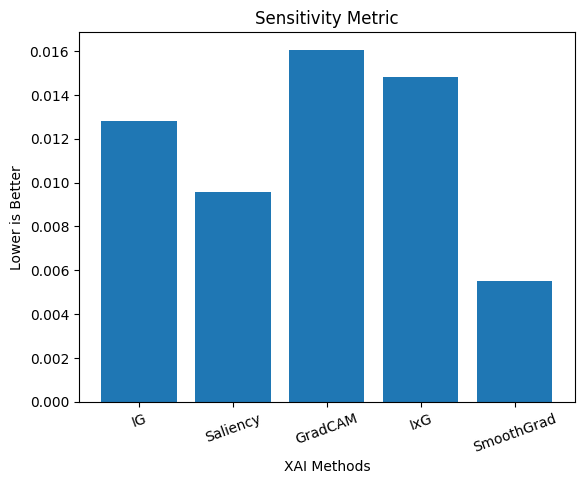

In [ ]:
methods = list(avg_results.keys())
metrics = ["deletion_black", "deletion_blur", "deletion_noise", "insertion_black", "insertion_blur", "insertion_noise", "infidelity", "sensitivity"]

for metric in metrics:
    scores = [avg_results[m][metric] for m in methods]

    plt.figure()
    plt.bar(methods, scores)
    plt.title(f"{metric.capitalize()} Metric")


    if metric in ["deletion", "infidelity", "sensitivity"]:
        plt.ylabel("Lower is Better")
    else:
        plt.ylabel("Higher is Better")

    plt.xlabel("XAI Methods")
    plt.xticks(rotation=20)

    plt.show()

In [ ]:
common_methods = ["IG", "IxG", "GradCAM", "Saliency"]

ranks = {}

metrics = ["deletion_black", "deletion_blur", "deletion_noise", "insertion_black", "insertion_blur", "insertion_noise", "infidelity", "sensitivity"]

for metric in metrics:

    reverse = True if metric == "insertion" else False

    ranking = sorted(
        avg_results.items(),
        key=lambda x: x[1][metric],
        reverse=reverse
    )

    print(f"\n{metric.upper()} Ranking:")
    for rank, (method, values) in enumerate(ranking, 1):
        print(f"{rank}. {method}: {values[metric]:.4f}")

    filtered = [(m, v) for m, v in ranking if m in common_methods]

    ranks[metric] = {}
    for new_rank, (method, values) in enumerate(filtered, 1):
        ranks[metric][method] = new_rank


DELETION_BLACK Ranking:
1. IG: 0.0290
2. IxG: 0.0408
3. SmoothGrad: 0.0559
4. Saliency: 0.0700
5. GradCAM: 0.0742

DELETION_BLUR Ranking:
1. IG: 0.4482
2. IxG: 0.4495
3. GradCAM: 0.6384
4. Saliency: 0.6468
5. SmoothGrad: 0.7173

DELETION_NOISE Ranking:
1. IG: 0.0297
2. IxG: 0.0432
3. SmoothGrad: 0.0572
4. GradCAM: 0.0700
5. Saliency: 0.0730

INSERTION_BLACK Ranking:
1. SmoothGrad: 0.1252
2. IxG: 0.1484
3. IG: 0.1769
4. Saliency: 0.3398
5. GradCAM: 0.5256

INSERTION_BLUR Ranking:
1. SmoothGrad: 0.0834
2. IxG: 0.0869
3. IG: 0.0978
4. Saliency: 0.2192
5. GradCAM: 0.3818

INSERTION_NOISE Ranking:
1. GradCAM: 0.0011
2. SmoothGrad: 0.0013
3. IxG: 0.0013
4. IG: 0.0013
5. Saliency: 0.0014

INFIDELITY Ranking:
1. SmoothGrad: 0.0078
2. GradCAM: 0.0080
3. IG: 0.0080
4. Saliency: 0.0081
5. IxG: 0.0083

SENSITIVITY Ranking:
1. SmoothGrad: 0.0055
2. Saliency: 0.0096
3. IG: 0.0128
4. IxG: 0.0148
5. GradCAM: 0.0161


In [ ]:
paper_ranks = {
    "deletion": {
        "IG": 1, "IxG": 2, "Saliency": 3, "GradCAM": 4
    },
    "insertion": {
        "IG": 1, "IxG": 2, "Saliency": 3, "GradCAM": 4
    },
    "infidelity": {
        "Saliency": 1, "IxG": 2, "GradCAM": 3, "IG": 4
    },
    "sensitivity": {
        "GradCAM": 1, "IG": 2, "IxG": 3, "Saliency": 4
    }
}

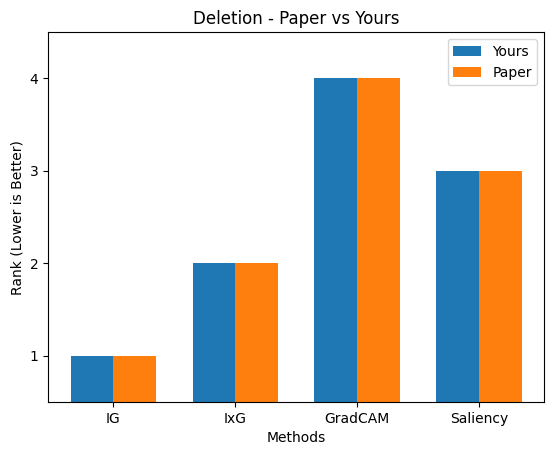

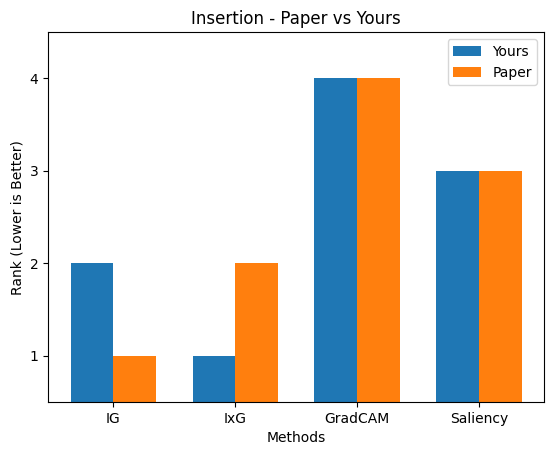

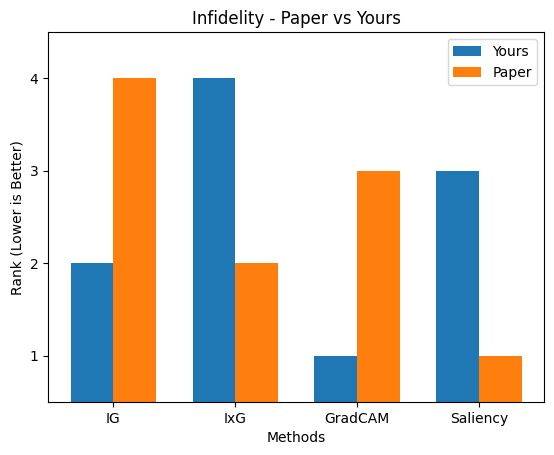

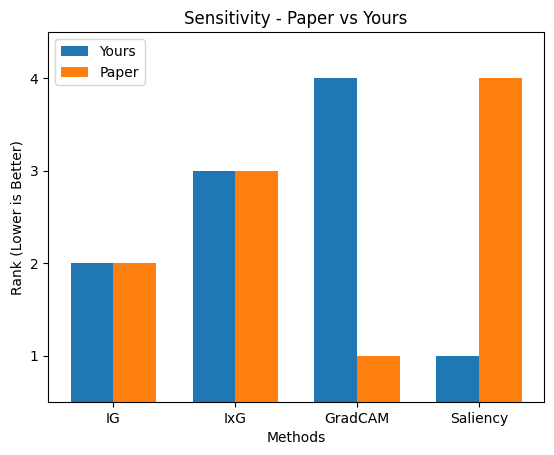

In [ ]:
common_methods = ["IG", "IxG", "GradCAM", "Saliency"]

metric_map = {
    "deletion": "deletion_black",
    "insertion": "insertion_black",
    "infidelity": "infidelity",
    "sensitivity": "sensitivity"
}

for metric in ["deletion", "insertion", "infidelity", "sensitivity"]:

    your_metric = metric_map[metric]

    your_vals = [ranks[your_metric][m] for m in common_methods]
    paper_vals = [paper_ranks[metric][m] for m in common_methods]

    x = np.arange(len(common_methods))
    width = 0.35

    plt.figure()
    plt.bar(x - width/2, your_vals, width, label="Yours")
    plt.bar(x + width/2, paper_vals, width, label="Paper")

    plt.xticks(x, common_methods)
    plt.yticks([1, 2, 3, 4])
    plt.ylim(0.5, 4.5)
    plt.title(f"{metric.capitalize()} - Paper vs Yours")
    plt.xlabel("Methods")
    plt.ylabel("Rank (Lower is Better)")
    plt.legend()

    plt.show()

In [ ]:
avg_results = {}

for method in methods:
    avg_results[method] = {}
    for metric in metrics:
        avg_results[method][metric] = np.mean(results[method][metric])

In [ ]:
normalized = {metric: {} for metric in metrics}

for metric in metrics:
    values = [avg_results[m][metric] for m in methods]
    min_v, max_v = min(values), max(values)

    for m in methods:
        val = avg_results[m][metric]

        norm = (val - min_v) / (max_v - min_v + 1e-8)

        normalized[metric][m] = norm

In [ ]:
aligned = {m: {} for m in methods}

for m in methods:
    aligned[m]["deletion_black"] = 1 - normalized["deletion_black"][m]
    aligned[m]["insertion_black"] = normalized["insertion_black"][m]
    aligned[m]["infidelity"] = 1 - normalized["infidelity"][m]
    aligned[m]["sensitivity"] = 1 - normalized["sensitivity"][m]

In [ ]:
final_scores = {}

for m in methods:
    final_scores[m] = (
        aligned[m]["deletion_black"] +
        aligned[m]["insertion_black"] +
        aligned[m]["infidelity"] +
        aligned[m]["sensitivity"]
    ) / 4

In [ ]:
sorted_methods = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)

print("\nFinal Combined Ranking:\n")
for rank, (method, score) in enumerate(sorted_methods, 1):
    print(f"{rank}. {method}: {score:.4f}")


Final Combined Ranking:

1. SmoothGrad: 0.6012
2. IG: 0.5258
3. GradCAM: 0.4214
4. Saliency: 0.4025
5. IxG: 0.2285


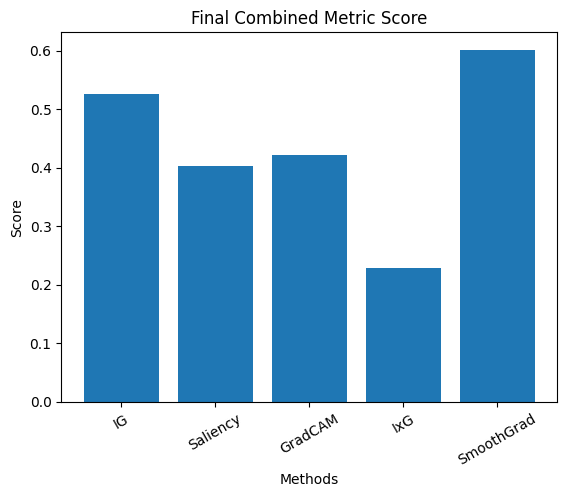

In [ ]:
methods_list = list(final_scores.keys())
scores = list(final_scores.values())

plt.figure()
plt.bar(methods_list, scores)
plt.title("Final Combined Metric Score")
plt.xlabel("Methods")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

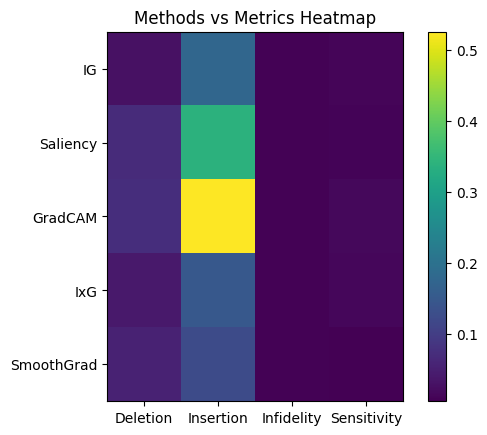

In [ ]:
selected_metrics = ["deletion_black", "insertion_black", "infidelity", "sensitivity"]

data = np.array([
    [avg_results[m][metric] for metric in selected_metrics]
    for m in methods
])

plt.figure()
plt.imshow(data)
plt.colorbar()

plt.xticks(range(len(selected_metrics)), ["Deletion", "Insertion", "Infidelity", "Sensitivity"])
plt.yticks(range(len(methods)), methods)

plt.title("Methods vs Metrics Heatmap")
plt.show()